In [1]:
import pandas as pd
df_factor = pd.read_parquet('final_feature_matrix_polished2.parquet')
df_factor

,TradingDate,Symbol,is_hs300,factor_mom_2d,factor_mom_5d,factor_mom_10d,factor_mom_20d,factor_reversal_5d,factor_pos_10d,factor_pos_20d,...,factor_turnover_chg,factor_illiquidity,factor_br,factor_avg_px_bias,factor_up_vol_ratio,factor_daily_pos,factor_pvt_20d,factor_turnover_bias,factor_pv_divergence,target_log_ret
0,2010-02-03,000001,True,-0.419412,0.613713,0.627402,0.541997,-0.613713,-0.236243,0.939585,...,0.167893,-0.591555,0.319372,-2.734753,-0.452381,-0.795573,0.477897,-0.238663,0.0,-0.016972
1,2010-02-03,000002,True,0.120885,0.268189,0.435331,-0.229261,-0.268189,-0.007128,-0.321460,...,-0.451399,-0.548991,-0.548896,-0.467890,-1.799874,-0.564989,-1.929665,-0.263356,0.0,-0.004242
2,2010-02-03,000009,True,-0.476138,0.544517,-0.632029,0.934315,-0.544517,-0.551340,-0.479064,...,-0.182673,-0.678319,1.264516,0.034123,1.131501,-0.054876,2.464601,-0.984421,0.0,0.095745
3,2010-02-03,000012,True,-1.256229,-1.338249,-1.340817,-0.825749,1.338249,-1.678090,-1.466028,...,0.443794,-0.025056,0.123518,-1.273525,-0.079102,0.248499,-0.857317,-0.397479,0.0,-0.003327
4,2010-02-03,000021,True,-0.355677,0.674963,0.227034,0.355731,-0.674963,-0.187312,-0.187903,...,-0.550184,0.844361,0.585947,-0.304910,0.440726,-0.199462,-0.528501,0.073503,0.0,0.009686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2334364,2024-12-30,688472,False,-0.053164,-0.020868,-0.579479,-0.265367,0.020868,-0.719673,-0.315587,...,-0.883087,-0.893420,0.897657,2.342325,-1.255127,0.252305,-1.113922,-2.094955,0.0,0.030727
2334365,2024-12-30,688506,False,2.798698,0.225661,0.466909,-0.980781,-0.225661,0.860256,-0.013906,...,1.671173,1.730541,0.825895,2.890364,-0.182732,1.066892,0.074647,0.811098,0.0,-0.005098
2334366,2024-12-30,688561,False,-0.840162,-0.387732,0.081418,-0.498613,0.387732,-0.277653,-0.325313,...,0.126780,0.968039,-0.297715,1.837282,-0.080424,-0.924835,-0.424770,0.638796,0.0,-0.051927
2334367,2024-12-30,688599,True,-1.202224,-2.026339,-1.993219,-0.849288,2.026339,-1.182325,-0.719093,...,0.940073,1.582597,-0.771212,2.222776,0.306306,-1.351603,0.245011,2.128963,0.0,-0.036625


沪深300成分股每日数量统计：
count    3620.000000
mean      290.120718
std        10.182993
min       131.000000
25%       285.000000
50%       292.000000
75%       299.000000
max       300.000000
Name: is_hs300, dtype: float64

前10天数据：
TradingDate
2010-02-03    239
2010-02-04    285
2010-02-05    289
2010-02-08    287
2010-02-09    289
2010-02-10    295
2010-02-11    293
2010-02-12    297
2010-02-22    296
2010-02-23    293
Name: is_hs300, dtype: int64


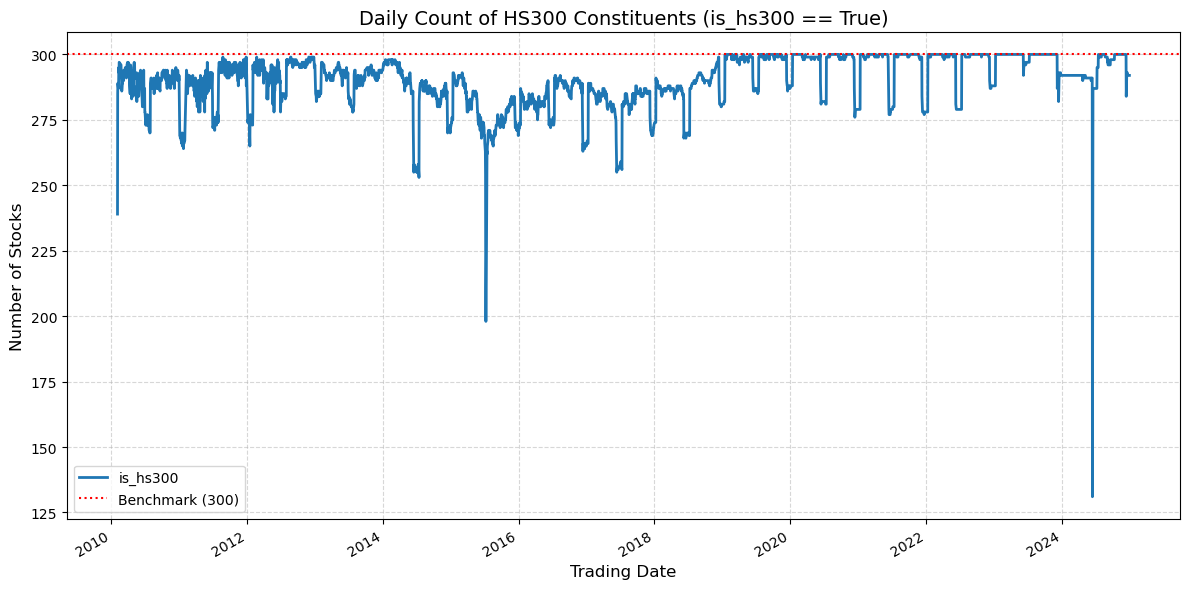

In [2]:
import matplotlib.pyplot as plt

# 1. 统计每天 is_hs300 为 True 的股票数量
# 假设 is_hs300 是布尔型，sum() 会统计 True 的数量
daily_hs300_count = df_factor.groupby('TradingDate')['is_hs300'].sum()

# 2. 打印基础统计信息查看
print("沪深300成分股每日数量统计：")
print(daily_hs300_count.describe())
print("\n前10天数据：")
print(daily_hs300_count.head(10))

# 3. 绘制趋势图
plt.figure(figsize=(12, 6))
daily_hs300_count.plot(kind='line', color='#1f77b4', linewidth=2)

# 图表美化
plt.title('Daily Count of HS300 Constituents (is_hs300 == True)', fontsize=14)
plt.xlabel('Trading Date', fontsize=12)
plt.ylabel('Number of Stocks', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=300, color='r', linestyle=':', label='Benchmark (300)') # 参考线
plt.legend()
plt.tight_layout()

# 保存并显示
plt.savefig('hs300_daily_count.png', dpi=300)
plt.show()